# Trabalho 2 – Análise Estrutural de Redes Urbanas
### Disciplina: Estrutura de Dados II (DCA3702)

**Região analisada:** Natal, Rio Grande do Norte, Brasil  
**Ferramentas:** OSMnx, NetworkX, Matplotlib, Seaborn

---

## Estrutura do Notebook

Este notebook contém o trabalho original e **cinco abordagens alternativas** que ampliam a análise:

| # | Abordagem | Descrição |
|---|---|---|
| 0 | **Original** | Análise base com métricas obrigatórias |
| 1 | **Comparação entre Bairros** | Análise estrutural comparativa entre regiões de Natal |
| 2 | **Vulnerabilidade da Rede** | Simulação de ataques direcionados vs. aleatórios |
| 3 | **Cruzamento com POIs** | Sobreposição de hubs com pontos de interesse urbano |
| 4 | **Centralidade Ponderada** | Betweenness e closeness com pesos reais de comprimento e velocidade |
| 5 | **Dashboard Comparativo** | Visualização consolidada de todas as métricas |

In [12]:
!pip install osmnx networkx matplotlib nxviz

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import pandas as pd
import osmnx as ox
import warnings

warnings.filterwarnings('ignore')

# Configuração visual padrão
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [14]:

# Inicializando com a Zona Norte de Natal-RNZona Norte,Natal
place = "Santa Cruz, Rio Grande do Norte, Brazil"

G = ox.graph_from_place(place, network_type="drive")

print("Carregando Santa Cruz\n")
print(G)
print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")


Carregando Santa Cruz

MultiDiGraph with 1984 nodes and 5346 edges
Número de nós: 1984
Número de arestas: 5346


In [15]:
# ============================================================
# Conversão: MultiDiGraph → Graph (não-direcionado)
# ------------------------------------------------------------
# CORREÇÃO: o grafo original era criado como nx.DiGraph(), o que é
# DIRECIONADO. core_number() e k_core() exigem grafo NÃO-DIRECIONADO.
# Usamos nx.Graph() e copiamos nós com todos os atributos originais
# (incluindo 'x'/'y' = longitude/latitude do OSMnx) para preservar
# a geolocalização na exportação.
# ============================================================

G_undirected = nx.Graph()

# Copiar nós preservando TODOS os atributos (inclusive x, y, lat, lon)
for node, data in G.nodes(data=True):
    G_undirected.add_node(node, **data)

# Copiar arestas sem duplicar (Graph já trata isso, mas mantemos a verificação)
for u, v, data in G.edges(data=True):
    if not G_undirected.has_edge(u, v):
        G_undirected.add_edge(u, v, **data)

# Remover self-loops
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

# Confirma que é não-direcionado
print(f"Tipo do grafo   : {type(G_undirected).__name__}  ← deve ser 'Graph'")
print(f"Nós             : {G_undirected.number_of_nodes()}")
print(f"Arestas         : {G_undirected.number_of_edges()}")

# Verifica presença de coordenadas nos nós
amostra = list(G_undirected.nodes(data=True))[:1]
no_id, no_data = amostra[0]
print(f"\nAtributos de um nó de exemplo (ID={no_id}):")
for k, v in no_data.items():
    print(f"  {k}: {v}")


Tipo do grafo   : Graph  ← deve ser 'Graph'
Nós             : 1984
Arestas         : 2783

Atributos de um nó de exemplo (ID=314993241):
  y: -6.1964319
  x: -36.0763806
  street_count: 1


In [16]:
#Grau dos Nós e Identificação de Hubs
degree_dict = dict(G_undirected.degree())

# Top 10 hubs por grau
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nós por grau (hubs):")
for rank, (node, deg) in enumerate(top_degree, 1):
    print(f"  {rank:2}. Nó {node} → grau {deg}")

Top 10 nós por grau (hubs):
   1. Nó 3964693509 → grau 6
   2. Nó 3964715642 → grau 5
   3. Nó 314993294 → grau 4
   4. Nó 1828181337 → grau 4
   5. Nó 2837621816 → grau 4
   6. Nó 2837621823 → grau 4
   7. Nó 2837621824 → grau 4
   8. Nó 2837621832 → grau 4
   9. Nó 2837621850 → grau 4
  10. Nó 2837621855 → grau 4


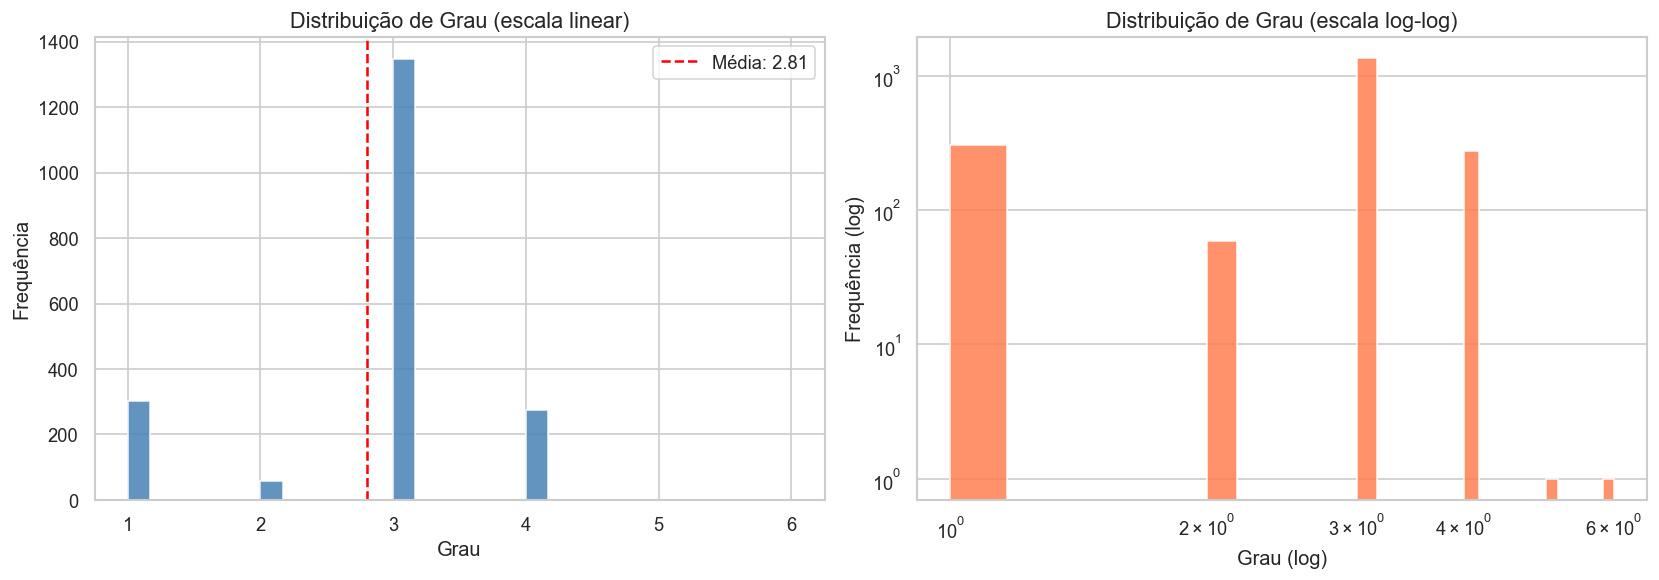

Grau médio   : 2.81
Grau mediano : 3.00
Grau máximo  : 6


In [17]:
# Distribuição de Grau
degrees = list(degree_dict.values())

pfig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma linear
axes[0].hist(degrees, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de Grau (escala linear)', fontsize=13)
axes[0].set_xlabel('Grau')
axes[0].set_ylabel('Frequência')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', label=f'Média: {np.mean(degrees):.2f}')
axes[0].legend()

# Histograma log-log (revela lei de potência)
axes[1].hist(degrees, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Distribuição de Grau (escala log-log)', fontsize=13)
axes[1].set_xlabel('Grau (log)')
axes[1].set_ylabel('Frequência (log)')

plt.tight_layout()
plt.savefig('distribuicao_grau.png', bbox_inches='tight')
plt.show()

print(f"Grau médio   : {np.mean(degrees):.2f}")
print(f"Grau mediano : {np.median(degrees):.2f}")
print(f"Grau máximo  : {max(degrees)}")


In [18]:
# Criar o  betweenness
print("Calculando betweenness (aproximado)...")
betweenness = nx.betweenness_centrality(G_undirected, k=500, normalized=True, seed=42)

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nós por betweenness:")
for rank, (node, val) in enumerate(top_betweenness, 1):
    print(f"  {rank:2}. Nó {node} → {val:.6f}")

Calculando betweenness (aproximado)...

Top 10 nós por betweenness:
   1. Nó 7428327102 → 0.152997
   2. Nó 7410672473 → 0.141740
   3. Nó 7413519201 → 0.135693
   4. Nó 7413476027 → 0.134679
   5. Nó 314993255 → 0.128743
   6. Nó 5233567955 → 0.125315
   7. Nó 7414103395 → 0.120022
   8. Nó 3964616875 → 0.119891
   9. Nó 3964720268 → 0.118441
  10. Nó 314993252 → 0.117077


In [19]:
# Criar o  closeness
print("Calculando closeness centrality...")
closeness = nx.closeness_centrality(G_undirected)

top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nós por closeness:")
for rank, (node, val) in enumerate(top_closeness, 1):
    print(f"  {rank:2}. Nó {node} → {val:.6f}")

Calculando closeness centrality...

Top 10 nós por closeness:
   1. Nó 7428327102 → 0.049233
   2. Nó 3964616875 → 0.049055
   3. Nó 7429003086 → 0.048988
   4. Nó 3964655751 → 0.048959
   5. Nó 3964720257 → 0.048878
   6. Nó 7436661174 → 0.048696
   7. Nó 3964720259 → 0.048690
   8. Nó 3964694000 → 0.048628
   9. Nó 314993296 → 0.048534
  10. Nó 7428559181 → 0.048515


In [22]:
# ============================================================
# K-Core Decomposition
# ------------------------------------------------------------
# nx.core_number() e nx.k_core() exigem grafo não-direcionado.
# Funcionam corretamente agora que G_undirected é nx.Graph().
# ============================================================

core_number = nx.core_number(G_undirected)
max_core = max(core_number.values())

k_core_graph = nx.k_core(G_undirected, k=max_core)

print(f"Maior core number (k-max): {max_core}")
print(f"Nós no k-core máximo     : {k_core_graph.number_of_nodes()}")
print(f"Arestas no k-core máximo : {k_core_graph.number_of_edges()}")
print(f"\nDistribuição dos core numbers:")

core_counts = pd.Series(core_number.values()).value_counts().sort_index()
print(core_counts)


Maior core number (k-max): 2
Nós no k-core máximo     : 1643
Arestas no k-core máximo : 2442

Distribuição dos core numbers:
1     341
2    1643
Name: count, dtype: int64


In [23]:
# ============================================================
# Adição de Métricas e Exportação para Gephi
# ------------------------------------------------------------
# O Gephi Geo Layout procura especificamente os campos
# "latitude" e "longitude" nos nós. O OSMnx armazena as
# coordenadas como "y" (latitude) e "x" (longitude).
# Por isso, renomeamos explicitamente antes de exportar.
# ============================================================

# Adicionar métricas calculadas como atributos dos nós
nx.set_node_attributes(G_undirected, degree_dict,  "degree")
nx.set_node_attributes(G_undirected, betweenness,  "betweenness")
nx.set_node_attributes(G_undirected, closeness,    "closeness")
nx.set_node_attributes(G_undirected, core_number,  "core_number")

# Renomear x/y -> longitude/latitude para compatibilidade com Gephi Geo Layout
for node, data in G_undirected.nodes(data=True):
    if "x" in data:
        data["longitude"] = data["x"]
    if "y" in data:
        data["latitude"] = data["y"]

# --- Limpeza das arestas ---
# GraphML nao suporta geometrias Shapely nem listas Python.
for u, v, data in G_undirected.edges(data=True):
    keys_remover = []
    keys_converter = {}
    for key, value in data.items():
        if key == "geometry":
            keys_remover.append(key)
        elif isinstance(value, list):
            keys_converter[key] = str(value)
        elif value is None:
            keys_converter[key] = ""
        elif not isinstance(value, (str, int, float, bool)):
            keys_remover.append(key)
    for key in keys_remover:
        del data[key]
    data.update(keys_converter)

# --- Limpeza dos nos ---
# "latitude" e "longitude" sao float e ficam protegidos pelo filtro de tipo.
# "x" e "y" originais tambem sao mantidos.
PRESERVAR = {"x", "y", "latitude", "longitude"}

for node, data in G_undirected.nodes(data=True):
    keys_remover = []
    keys_converter = {}
    for key, value in data.items():
        if key in PRESERVAR:
            continue
        elif isinstance(value, list):
            keys_converter[key] = str(value)
        elif value is None:
            keys_converter[key] = ""
        elif not isinstance(value, (str, int, float, bool)):
            keys_remover.append(key)
    for key in keys_remover:
        del data[key]
    data.update(keys_converter)

# --- Exportacao ---
NOME_ARQUIVO = "Santa-Cruz.graphml"
nx.write_graphml(G_undirected, NOME_ARQUIVO)
print(f"Arquivo '{NOME_ARQUIVO}' exportado com sucesso!")
print(f"  -> Nos   : {G_undirected.number_of_nodes()}")
print(f"  -> Arestas: {G_undirected.number_of_edges()}")

# Verificacao: confirma presenca de latitude e longitude
amostra_no = list(G_undirected.nodes(data=True))[0]
node_id, node_data = amostra_no
print(f"\nVerificacao no no {node_id}:")
print(f"  latitude  = {node_data.get('latitude',  'NAO ENCONTRADO')}")
print(f"  longitude = {node_data.get('longitude', 'NAO ENCONTRADO')}")


Arquivo 'Santa-Cruz.graphml' exportado com sucesso!
  -> Nos   : 1984
  -> Arestas: 2783

Verificacao no no 314993241:
  latitude  = -6.1964319
  longitude = -36.0763806
